In [2]:
import pandas as pd
import pickle
import numpy as np
import talib
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
with open('../../data/nifty_data.pkl', 'rb') as file:
    nifty_data = pickle.load(file)

In [4]:
# download data for 
# S&P 500
# USDINR
# Gold
# India VIX
# ^NSEBANK
# ^CNXIT
# ^CNXFMCG

# sp500_data = yf.Ticker('^GSPC').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# usdinr_data = yf.Ticker('USDINR=X').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# gold_data = yf.Ticker('GC=F').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)  
# vix_data = yf.Ticker('^INDIAVIX').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# nse_bank_data = yf.Ticker('^NSEBANK').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# cnx_it_data = yf.Ticker('^CNXIT').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# cnx_fmcg_data = yf.Ticker('^CNXFMCG').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)

In [5]:
# with open('../../data/sp500_data.pkl', 'wb') as file:
#     pickle.dump(sp500_data, file)
# with open('../../data/usdinr_data.pkl', 'wb') as file:
#     pickle.dump(usdinr_data, file)
# with open('../../data/gold_data.pkl', 'wb') as file:
#     pickle.dump(gold_data, file)
# with open('../../data/vix_data.pkl', 'wb') as file:
#     pickle.dump(vix_data, file)
# with open('../../data/nse_bank_data.pkl', 'wb') as file:
#     pickle.dump(nse_bank_data, file)
# with open('../../data/cnx_it_data.pkl', 'wb') as file:
#     pickle.dump(cnx_it_data, file)

with open('../../data/sp500_data.pkl', 'rb') as file:
    sp500_data = pickle.load(file)
with open('../../data/usdinr_data.pkl', 'rb') as file:
    usdinr_data = pickle.load(file)
with open('../../data/gold_data.pkl', 'rb') as file:
    gold_data = pickle.load(file)
with open('../../data/vix_data.pkl', 'rb') as file:
    vix_data = pickle.load(file)
with open('../../data/nse_bank_data.pkl', 'rb') as file:
    nse_bank_data = pickle.load(file)
with open('../../data/cnx_it_data.pkl', 'rb') as file:
    cnx_it_data = pickle.load(file)

In [6]:
# create a 

In [ ]:
from dataclasses import dataclass
from typing import Dict
from pydantic import BaseModel, ConfigDict
from typing_extensions import Literal
import enum
import numpy as np
import pandas as pd
import yfinance as yf
import pickle

# create a enum for the stock names
class StockName(enum.Enum):
    NIFTY = "nifty_data"
    SP500 = "sp500_data"
    USDINR = "usdinr_data"
    GOLD = "gold_data"
    VIX = "vix_data"
    NSE_BANK = "nse_bank_data"
    CNX_IT = "cnx_it_data"


stocks = [
    {"name": "nifty_data", "ticker": "^NSEI"},
    {"name": "sp500_data", "ticker": "^GSPC"},
    {"name": "usdinr_data", "ticker": "USDINR=X"},
    {"name": "gold_data", "ticker": "GC=F"},
    {"name": "vix_data", "ticker": "^INDIAVIX"},
    {"name": "nse_bank_data", "ticker": "^NSEBANK"},
    {"name": "cnx_it_data", "ticker": "^CNXIT"},
]

class OHLCVData(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    name: Literal["nifty_data", "sp500_data", "usdinr_data", "gold_data", "vix_data", "nse_bank_data", "cnx_it_data"]
    data: pd.DataFrame

class DataObject(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    nifty_data: OHLCVData
    sp500_data: OHLCVData
    usdinr_data: OHLCVData
    gold_data: OHLCVData
    vix_data: OHLCVData
    nse_bank_data: OHLCVData
    cnx_it_data: OHLCVData

class YahooFinanceDataLoader:
    def __init__(self, stock: Dict[str, str], use_local: bool = False):
        self.stock = stock
        self.use_local = use_local

    def load_data(self, ticker: str, start: str, end: str) -> pd.DataFrame:
        return yf.Ticker(ticker).history(start=start, end=end, auto_adjust=True)
    
   
    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df.index = df.index.tz_localize(None)
        df = df[["Close", "Open", "High", "Low", "Volume"]]
        return df
    
    def run(self, start: str|None, end: str|None) -> DataObject:
        data_dict = {}
        for key, ticker in self.stock.items():
            if self.use_local:
                with open(f'../../data/{key}.pkl', 'rb') as file:
                    raw_data = pickle.load(file)
            else:
                raw_data = self.load_data(ticker, start, end)
            cleaned_data = self.clean_data(raw_data)
            data_dict[key] = OHLCVData(name=key, data=cleaned_data)
        return DataObject(**data_dict)
    
    

    
FEATURES = [
    "rolling_sharpe_20",
    "rolling_max_dd_60",

    "realized_vol_20",
    "vol_slope_20",

    "autocorr_20",

    "rel_spx_20",
    "usdinr_vol_20",
    "rel_gold_20",
    "vix_level_20",

    "vix_slope_20",
    "trend_strength_200",

    "sector_dispersion_ratio_20",
]

@dataclass(frozen=True)
class FeatureConfig:
    sharpe_window: int = 20
    max_dd_window: int = 60
    vol_window: int = 20
    autocorr_window: int = 20
    rel_window: int = 20
    vix_window: int = 20
    trend_window: int = 200
    sector_window: int = 20
    epsilon: float = 1e-8

class FeatureEngineer:
    def __init__(self, all_data: DataObject, config: FeatureConfig | None = None):
        self.config = config or FeatureConfig()
        self.all_data = self._align_all_data(all_data)
        self.df = self.all_data.nifty_data.data.copy()
        self.div_zero_counts: Dict[str, int] = {}

    def _align_all_data(self, all_data: DataObject) -> DataObject:
        base_index = all_data.nifty_data.data.index
        def align(df: pd.DataFrame) -> pd.DataFrame:
            aligned = df.reindex(base_index).copy()
            aligned = aligned.ffill().bfill()
            return aligned

        fields = [
            "nifty_data",
            "sp500_data",
            "usdinr_data",
            "gold_data",
            "vix_data",
            "nse_bank_data",
            "cnx_it_data",
        ]
        data_dict = {}
        for field in fields:
            ohlcv = getattr(all_data, field)
            data_dict[field] = OHLCVData(name=ohlcv.name, data=align(ohlcv.data))
        return DataObject(**data_dict)
    
    def _safe_div(self, numerator: pd.Series, denominator: pd.Series, label: str) -> pd.Series:
        zero_mask = denominator == 0
        self.div_zero_counts[label] = int(zero_mask.sum())
        denom = denominator.mask(zero_mask, self.config.epsilon)
        return numerator / denom

    def get_div_zero_counts(self) -> pd.Series:
        return pd.Series(self.div_zero_counts).sort_values(ascending=False)

    def compute_sector_dispersion(self, market_vol: pd.Series) -> pd.Series:
        cfg = self.config
        nse_bank_data = self.all_data.nse_bank_data.data
        cnx_it_data = self.all_data.cnx_it_data.data

        sector_df = pd.DataFrame({
            "nse_bank": nse_bank_data["Close"],
            "cnx_it": cnx_it_data["Close"],
        })
        sector_returns = np.log(sector_df / sector_df.shift(1))
        daily_dispersion = sector_returns.std(axis=1)
        dispersion = daily_dispersion.rolling(cfg.sector_window, min_periods=cfg.sector_window).mean()
        # print null counts for dispersion and market_vol
        print(f"Null counts - dispersion: {dispersion.isnull().sum()}, market_vol: {market_vol.isnull().sum()}", sector_df.isnull().sum().sum())
        # return self._safe_div(dispersion, market_vol, "sector_dispersion_ratio_20")
        return dispersion/market_vol

    def compute_features(self) -> pd.DataFrame:
        cfg = self.config
        df = self.df
        sp500_data = self.all_data.sp500_data.data
        usdinr_data = self.all_data.usdinr_data.data
        gold_data = self.all_data.gold_data.data
        vix_data = self.all_data.vix_data.data

        log_ret = np.log(df["Close"] / df["Close"].shift(1))
        features = pd.DataFrame(index=df.index)

        sharpe_mean = log_ret.rolling(cfg.sharpe_window, min_periods=cfg.sharpe_window).mean()
        sharpe_std = log_ret.rolling(cfg.sharpe_window, min_periods=cfg.sharpe_window).std()
        features["rolling_sharpe_20"] = self._safe_div(sharpe_mean, sharpe_std, "rolling_sharpe_20")

        rolling_max = df["Close"].rolling(cfg.max_dd_window, min_periods=cfg.max_dd_window).max()
        drawdown = df["Close"] / rolling_max - 1.0
        features["rolling_max_dd_60"] = drawdown.rolling(cfg.max_dd_window, min_periods=cfg.max_dd_window).min()

        features["realized_vol_20"] = np.sqrt((log_ret ** 2).rolling(cfg.vol_window, min_periods=cfg.vol_window).sum())
        features["vol_slope_20"] = features["realized_vol_20"].diff()

        features["autocorr_20"] = log_ret.rolling(cfg.autocorr_window, min_periods=cfg.autocorr_window).apply(
            lambda x: x.autocorr(lag=1),
            raw=False,
        )

        features["rel_spx_20"] = (
            np.log(df["Close"] / df["Close"].shift(cfg.rel_window))
            - np.log(sp500_data["Close"] / sp500_data["Close"].shift(cfg.rel_window))
        )
        features["usdinr_vol_20"] = (
            np.log(usdinr_data["Close"] / usdinr_data["Close"].shift(1))
            .rolling(cfg.vol_window, min_periods=cfg.vol_window)
            .std()
        )
        features["rel_gold_20"] = (
            np.log(df["Close"] / df["Close"].shift(cfg.rel_window))
            - np.log(gold_data["Close"] / gold_data["Close"].shift(cfg.rel_window))
        )
        features["vix_level_20"] = vix_data["Close"].rolling(cfg.vix_window, min_periods=cfg.vix_window).mean()
        features["vix_slope_20"] = vix_data["Close"].diff().rolling(cfg.vix_window, min_periods=cfg.vix_window).mean()

        trend_mean = df["Close"].rolling(cfg.trend_window, min_periods=cfg.trend_window).mean()
        trend_std = df["Close"].rolling(cfg.trend_window, min_periods=cfg.trend_window).std()
        features["trend_strength_200"] = self._safe_div(df["Close"] - trend_mean, trend_std, "trend_strength_200")

        market_vol = log_ret.rolling(cfg.sector_window, min_periods=cfg.sector_window).std()
        features["sector_dispersion_ratio_20"] = self.compute_sector_dispersion(market_vol)

        features["Close"] = df["Close"]
        return features

    def standardize_features(self, df: pd.DataFrame) -> pd.DataFrame:
        mean = df[FEATURES].mean()
        std = df[FEATURES].std().replace(0, np.nan)
        df.loc[:, FEATURES] = (df[FEATURES] - mean) / (std + 1e-8)
        return df

    def run(self) -> pd.DataFrame:
        features = self.compute_features()
        features = features.dropna()
        features = self.standardize_features(features)
        self.save_output(features, '../../data/nifty_features.pkl')
        return features[FEATURES + ["Close"]]
    
    def save_output(self, df: pd.DataFrame, filename: str):
        output = {
            "features": df,
            "mean": df[FEATURES].mean(),
            "std": df[FEATURES].std(),
        }

        with open(filename, 'wb') as file:
            pickle.dump(output, file)

# Usage


In [8]:
data_loader = YahooFinanceDataLoader(stock={stock["name"]: stock["ticker"] for stock in stocks}, use_local=True)
all_data = data_loader.run(start=None, end=None)

In [9]:
all_data.usdinr_data.data.head()

,Close,Open,High,Low,Volume
Date,,,,,
2007-09-17,40.376999,40.430000,40.560001,40.363998,0
2007-09-18,40.216999,40.380001,40.599998,40.165001,0
2007-09-19,40.033001,40.220001,40.294998,39.945000,0
2007-09-20,39.615002,40.040001,40.042000,39.603001,0
2007-09-21,39.770000,39.619999,39.889999,39.587002,0


In [10]:
feature_engineer = FeatureEngineer(all_data)
df_features = feature_engineer.run()

Null counts - dispersion: 20, market_vol: 20 0


In [11]:
feature_engineer.get_div_zero_counts()

rolling_sharpe_20     0
trend_strength_200    0
dtype: int64

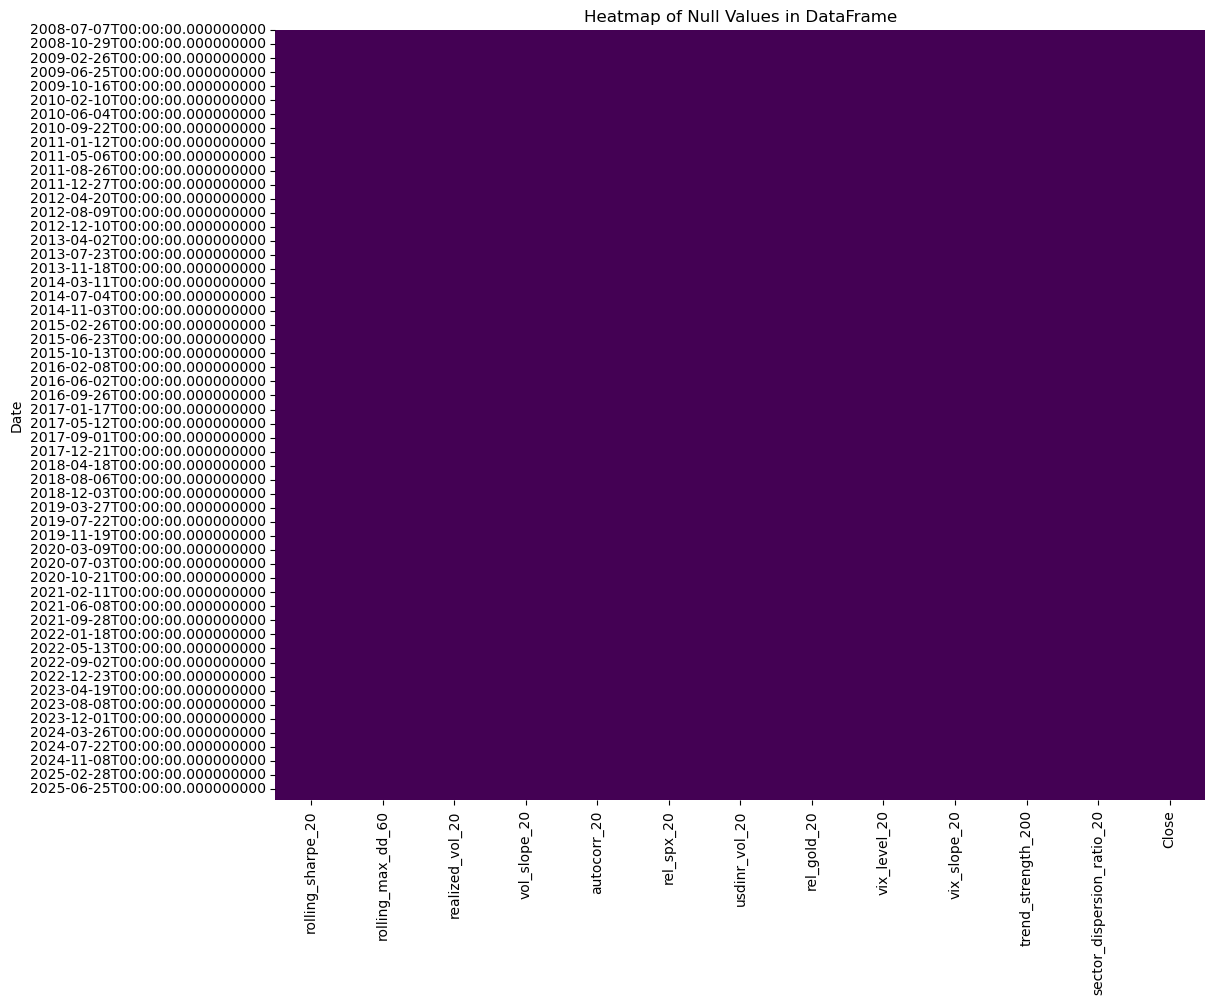

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_features.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Null Values in DataFrame')
plt.show()

<Axes: xlabel='sector_dispersion_ratio_20', ylabel='Count'>

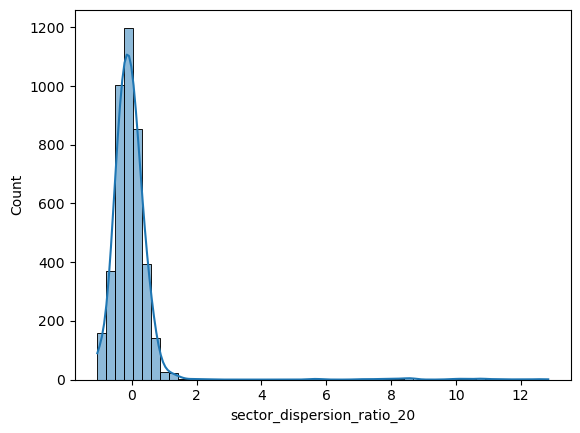

In [13]:
sns.histplot(df_features["sector_dispersion_ratio_20"], bins=50, kde=True)

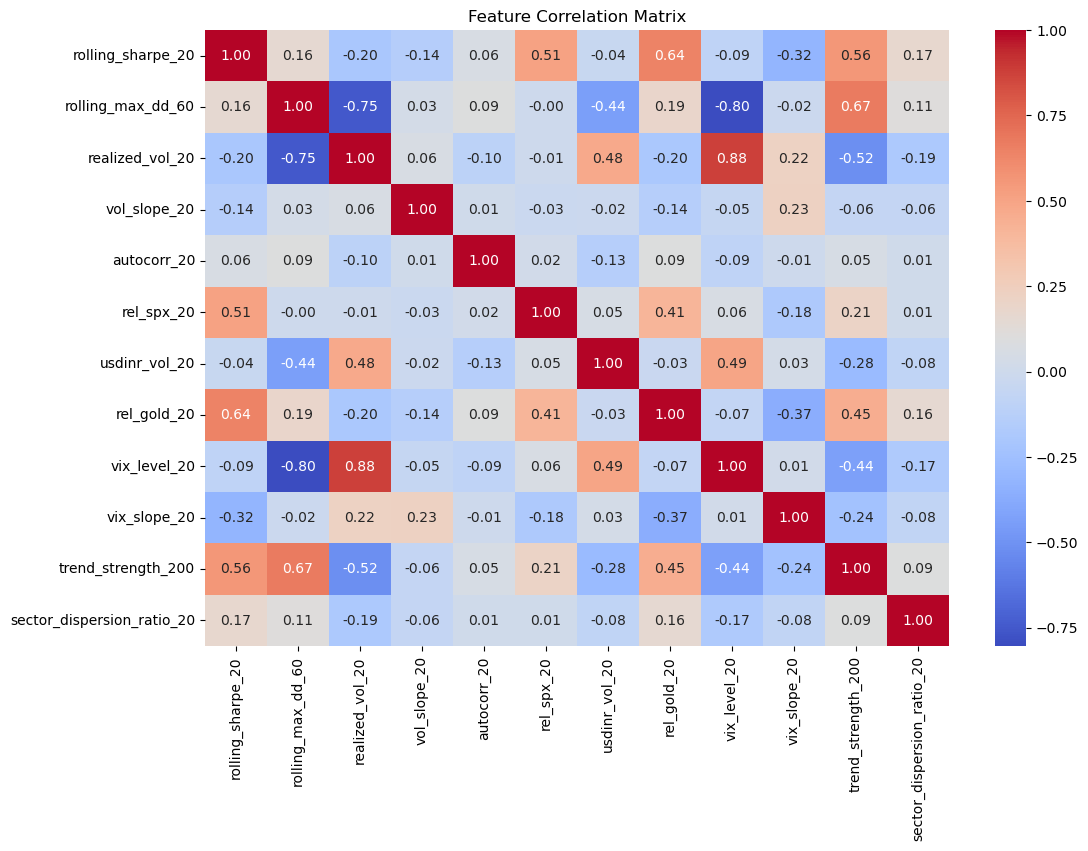

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_features[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()